In [2]:
import numpy as np
import torch 
import gymnasium as gym
import matplotlib.pyplot as plt

from copy import deepcopy
from tqdm import tqdm
from four_room.env import FourRoomsEnv
from four_room.wrappers import gym_wrapper
from four_room.constants import state_to_q
from rnd_exploration.dataset import State
from four_room.constants import train_config, val_config, test_config, size
from uvu.uvu import UVU
from dqn.model import DQN
from utils.episode import LastEpisode
from utils.record_scores import record_uvu_scores, record_dqn_scores
%load_ext autoreload
%autoreload 2

In [4]:
gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'][:1],
            goal_pos = train_config['goal positions'][:1],
            doors_pos = train_config['topologies'][:1],
            agent_dir = train_config['agent directions'][:1],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )
    
val_env = gym_wrapper(gym.make(
        'MiniGrid-FourRooms-v1', 
        agent_pos= train_config['agent positions'][:1],
        goal_pos = train_config['goal positions'][:1],
        doors_pos = train_config['topologies'][:1],
        agent_dir = train_config['agent directions'][:1],
        size=size
    ),
    original_obs=True
)

c:\Users\garga\Documents\Uni\RND DQN\four_room\venv\Lib\site-packages\gymnasium\envs\registration.py:694: UserWarning: WARN: Overriding environment MiniGrid-FourRooms-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [42]:
agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    device='cuda',
    use_cnn=True,
    cnn_features=1024,
    hidden_layers=[1024, 1024, 1024, 1024],
    hidden_layers_g=[64],
    residual=True,
    init='orthogonal'
)

In [43]:
done = False
last_ep = LastEpisode(env.observation_space.shape, capacity=10)
# env.get_wrapper_attr('set_context')(0)
obs, _ = env.reset()
for step in tqdm(range(1, 5000)):
    q = state_to_q[State(state=obs)]
    action = q.argmax() if isinstance(q, np.ndarray) else np.array(q).argmax()
    
    obs_prime, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    q_next = state_to_q[State(state=obs_prime)] if not done else np.array([0, 0, 0])
    next_action = q_next.argmax()
    agent.buffer.update(obs, action, reward, obs_prime, next_action, int(done), q_value=q)
    last_ep.update(obs, action, obs_prime, next_action, int(done), None)
    
    if agent.buffer.size > 512:
        agent.update_step(512, last_ep)
        agent.soft_update()
    
    obs = obs_prime
    if done:
        # env.get_wrapper_attr('set_context')(0)
        obs, _ = env.reset()

100%|██████████| 4999/4999 [02:09<00:00, 38.47it/s]


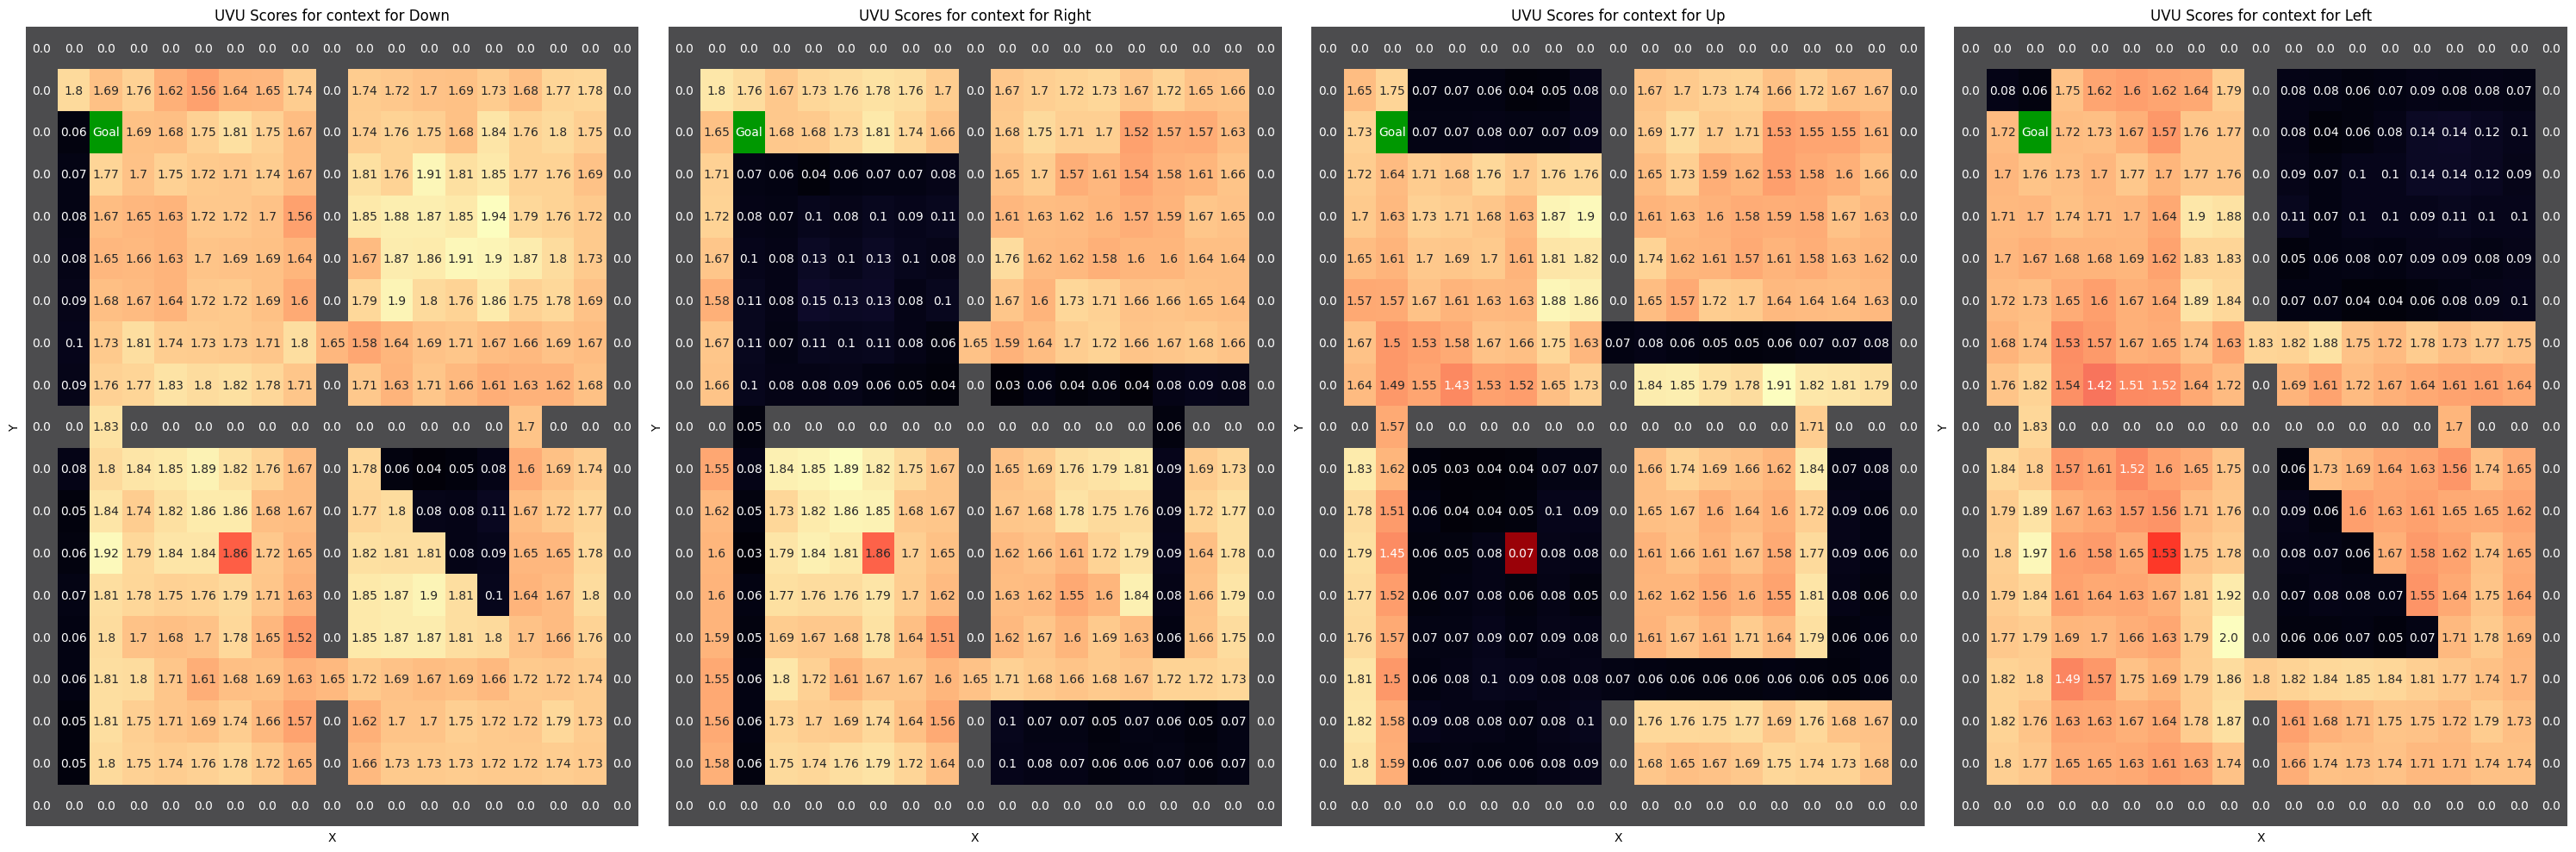

In [10]:
from plot_interactive import find_states, plot_env_heatmap

agent = UVU(
    env=env,
    val_env=val_env,
    capacity=1000,
    tau=0.01,
    lr=3e-4,
    device='cuda',
    use_cnn=True,
    cnn_features=1024,
    hidden_layers=[1024, 2048, 1024],
    hidden_layers_g=[64],
    residual=True,
    init='orthogonal'
)

# agent = DQN(
#     env=env,
#     val_env=val_env,
#     capacity=1000,
#     tau=0.001,
#     lr=3e-4,
#     device='cuda',
#     use_cnn=True,
#     cnn_features=1024,
#     hidden_layers=[1024, 2048, 1024],
#     residual=True
# )

fig, axes = plt.subplots(1, 4, figsize=(30, 10))
context = 0
_, _, uvu_scores = record_uvu_scores(agent, context, 0)
env.get_wrapper_attr('set_context')(context)
obs, _ = env.reset()
context_info = env.get_wrapper_attr('context_info')(context)
context_info = (*context_info, env.get_wrapper_attr('valid_pos'))
agent_pos = env.get_wrapper_attr('agent_pos')

plot_env_heatmap(
    uvu_scores[0].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Down',
    axes[0],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[1].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Right',
    axes[1],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[2].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Up',
    axes[2],
    agent_pos=agent_pos,
    intize=False
)

plot_env_heatmap(
    uvu_scores[3].squeeze(),
    context_info,
    'UVU Scores',
    f'UVU Scores for context for Left',
    axes[3],
    agent_pos=agent_pos,
    intize=False
)


plt.tight_layout()
